<a href="https://colab.research.google.com/github/hasindu-nagolla/pdf-rag-deepseek/blob/main/pdf_rag_deepseek_bge_faiss.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import sys
import torch

print("Py -v: ", sys.version)
print("PyTorch -v: ", torch.__version__)
print("GPU available: ", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Py -v:  3.13.15 (main, Aug  6 2026, 11:06:23) [GCC 11.4.0]
PyTorch -v:  2.11.0+cu128
GPU available:  True
GPU: Tesla T4


## Installing the RAG tools

install the libraries,


1. pymupdf -  read PDF and extract text
2. sentence-transformers - gives easy way to use embedding models lke BAAI/bge-small-en-v1.5
3. faiss-cpu -
4. transformers - from Hugging Face and will allow to load DeepSeek model
5. accelerate - help to run large models more efficiently across available hardware
6. bitsandbytes - will be useful when look at quantization
7. gradio - Python RAG pipeline into UI

In [2]:
!pip install -q pymupdf sentence-transformers faiss-cpu transformers accelerate bitsandbytes gradio

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.8/25.8 MB 80.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.8/18.8 MB 105.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.1/43.1 MB 16.4 MB/s eta 0:00:00


# **Part 2 — Loading the PDF**


Now we start working with the a knowledge source. how python get information from a PDF? bcz PDF is not stored text as plain tect that python can be directly use. so, we need a PDF-processing library to open it and extract its contents. therefore we are using PyMuPDF because our RAG system ultimately needs text, not a PDF file itself.



In [3]:
# upload the PDF
from google.colab import files
uploaded = files.upload()

Saving Finance_RAG_20_Page_Real_Data.pdf to Finance_RAG_20_Page_Real_Data.pdf


In [4]:
pdf_file = list(uploaded.keys())[0]
print("PDF file:", pdf_file)

PDF file: Finance_RAG_20_Page_Real_Data.pdf


### Open the PDF with PyMuPDF

now we have a PDF. then we need to open the actual document using PyMuPDF

In [5]:
import pymupdf

doc = pymupdf.open(pdf_file) # Open the PDF and create a Document object. then we can interact with PDF using "doc"
print("Number of pages:", len(doc))

Number of pages: 20


### Access a single page

how PyMuPDF represent a page?

In [6]:
page = doc[0]
print("Page number: ", page.number)

# we are using 0 bcz zero indexed

Page number:  0


### Extract text from that page



In [7]:
text = page.get_text("text")
print(text[:2000])

## extract text content from the PDF, 1st page. and force to show only 2000 characters

Finance RAG Evaluation Corpus — public SEC filing data
Page 1
Finance RAG Evaluation Corpus — 20 Pages
Company 1 of 4 — Apple Inc. (AAPL)
Fiscal period: FY2025 ended September 27, 2025
Primary source: SEC Form 10-K, filed October 31, 2025
Purpose: grounded financial retrieval, numeric QA, comparison and entity disambiguation.
Metric
2025
2024
2023
Net sales
$416,161m
$391,035m
$383,285m
Gross margin
$195,201m
$180,683m
$169,148m
Operating income
$133,050m
$123,216m
$114,301m
Net income
$112,010m
$93,736m
$96,995m
Diluted EPS
$7.46
$6.08
$6.13
Business and revenue structure
Apple reported total net sales of $416.161 billion in fiscal 2025. Services generated $109.158 billion and iPhone generated
$209.586 billion. The filing states that iPhone growth was primarily driven by higher sales of Pro models; Services growth was
primarily driven by advertising, the App Store and cloud services.



**Why page-by-page?**

bcz our code will not simply do the entire PDF into one giant string. instead, we extract 1 by 1

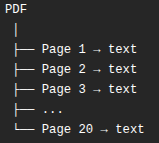

bcz, we will retrive a chunk later. so we want to know,

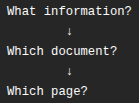

this makes RAG system more useful.

### Extract the Entire PDF

We successfully learned how to extract text from one page. Now we need to do the same thing for every page in the pdf


In [8]:
pages = []

for page_number, page in enumerate(doc):
  text = page.get_text("text")

  pages.append({
      "page": page_number + 1,
      "text": text
  })

print("Pages extracted:", len(pages))

"""
in this block;

we creating a empty array and it loop through every page.
page.get_text("text") with extract the actual text as a string
"""

Pages extracted: 20


'\nin this block;\n\nwe creating a empty array and it loop through every page.\npage.get_text("text") with extract the actual text as a string\n'

### Inspect what we created

Now lets look the first item. we can see something conceptually

```
{
    'page': 1,
    'text': 'Finance RAG Evaluation Corpus...'
}
```

We have created a structured representation of PDF. Instead of having a unstructured PDF, we have now,



```
[
    {
        "page": 1,
        "text": "..."
    },
    {
        "page": 2,
        "text": "..."
    },
    ...
]
```

Because later we need to create chunks. The page number is metadata. This means the text and its origin stay connected.

For example,


```
Chunk:
"Apple reported total net sales..."

Metadata:
{
    page: 1,
    source: "Finance_RAG_20_Page_Real_Data.pdf"
}
```
Later, when DeepSeek answers a question, we can tell the user where the evidence came from.





# **Part 3 — Chunking the Document**

no we have PDF => 20 pages => extracted text, but we do not feed entire page or PDF into the model ad a one piece. we need to devide the text into chunks

### **what is a chunk and why do we need chuncking?**

it is a smaller section of the original document. for a example, assume a user asks "how much did apple's service business genarate?". the relevent info is very small part of the PDF. we dont need to 20 page entire document.

instead, we want like;

```
Question
    🡳
Find relevant chunk
    🡳
"Services generated $109.158 billion..."
```

after that, LLM can use this relevent information.

### **Chunking is a trade-off**

This is a very important RAG concept. the chuncks should be balance, we need to find the right middle point. if chunk is too large, we gets lots of irrelevent information, otherwise we may lose the context.

for a example;



```
Chunk A:
"Services generated..."

Chunk B:
"$109.158 billion."
```
The information has been separated. So we want a reasonable chunk size. therefore, we are using 800 characters per chunk and 150 overlapping between neigbers chunks.

Overlapping means that the end of one chunk is repeated at the beginning of the next chunk. think like this,

```
Chunk 1
├──────────────────────────────┤
0                            800

             Chunk 2
             ├──────────────────────────────┤
             650                          1450

                         Chunk 3
                         ├──────────────────────────────┤
                         1300                       2100
```



In [10]:
CHUNK_SIZE = 800
OVERLAP = 150

chunks = []

for page_data in pages:
    text = page_data["text"]
    page_number = page_data["page"]

    start = 0

    while start < len(text):
        end = start + CHUNK_SIZE
        chunk_text = text[start:end]

        if chunk_text.strip():
            chunks.append({
                "text": chunk_text,
                "page": page_number,
                "source": pdf_file
            })

        start += CHUNK_SIZE - OVERLAP

print("Total chunks:", len(chunks))

Total chunks: 33


in this, we are not storing only


```
{
    "text": chunk_text
}
```

we are storing metadata also

```
{
    "text": chunk_text,
    "page": page_number,
    "source": pdf_file
}
```

So, conceotully its look like,

```
{
    text: "Apple reported total net sales...",
    page: 1,
    source: "Finance_RAG_20_Page_Real_Data.pdf"
}
```

In [1]:
# Inspect our first chunk

print(chunks[0]["text"])
print("\nPage:", chunks[0]["page"])
print("Source:", chunks[0]["source"])

NameError: name 'chunks' is not defined

We still not converted anything into vectors. our current architecture is

```
                 PDF
                  ↓
              PyMuPDF
                  ↓
             Page text
                  ↓
              Chunking
                  ↓
        ┌─────────────────────┐
        │ Chunk 1 + metadata  │
        │ Chunk 2 + metadata  │
        │ Chunk 3 + metadata  │
        │        ...          │
        └─────────────────────┘
```

our chunks are still ordinary Python strings.

# **Part 4 — BGE Embeddings**

our new question is, how can a computer determine which chunk is relevant to a user's question based on meaning?

thats what embeddings slove

#### **What is embedding?**

it is a numerical representation of the text. we can take example like,
```
"Apple reported total net sales of $416.161 billion."
```
our embedding model convert it into a vector like,
```
[0.021, -0.184, 0.073, ..., 0.412]
```

we do not need to interpret each individual number

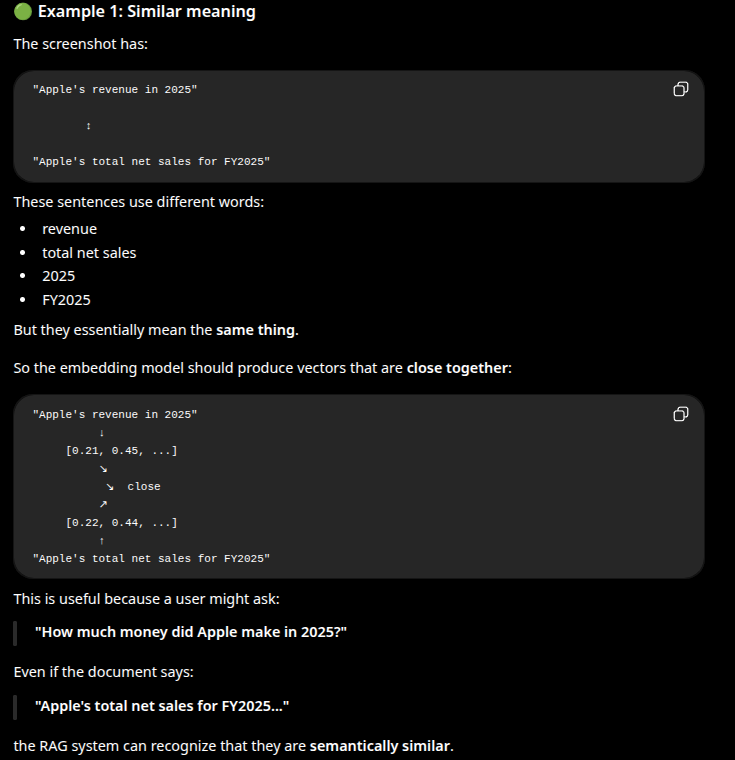

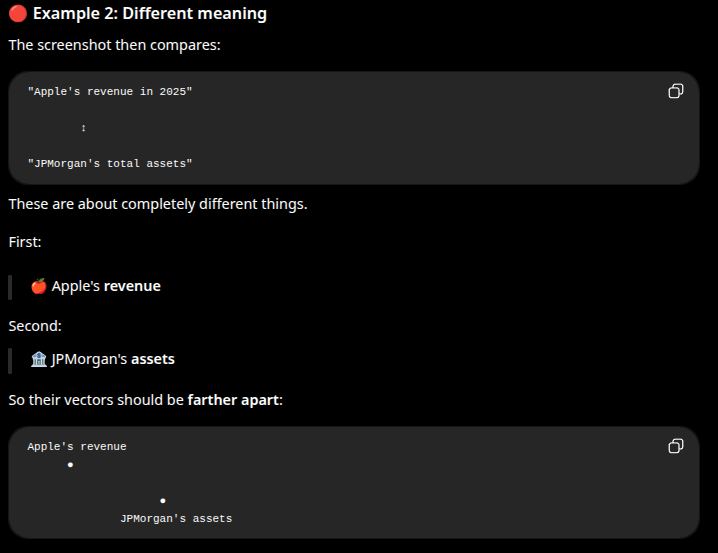


#### **BGE is our embedding model**

then we are going to use `BAAI/bge-small-en-v1.5` BGE is an embedding model developed by BAAI (Beijing Academy of Artificial Intelligence).

